## Setup

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.width', 200)

p = pd.read_parquet('../data/interim/dispatchprice.parquet')
d = pd.read_parquet('../data/interim/dispatchregionsum.parquet')

df = p[['SETTLEMENTDATE','REGIONID','RRP']].merge(
    d[['SETTLEMENTDATE','REGIONID','TOTALDEMAND','DEMANDFORECAST',
       'AVAILABLEGENERATION','UIGF','TOTALINTERMITTENTGENERATION',
       'SEMISCHEDULE_CLEAREDMW','NETINTERCHANGE']],
    on=['SETTLEMENTDATE','REGIONID'], how='inner')

df['hour']   = df.SETTLEMENTDATE.dt.hour
df['month']  = df.SETTLEMENTDATE.dt.month
df['dow']    = df.SETTLEMENTDATE.dt.dayofweek
df['margin'] = df.AVAILABLEGENERATION - df.TOTALDEMAND
df['uigf_err'] = df.TOTALINTERMITTENTGENERATION - df.UIGF

print(df.shape)
df.head()

(1883520, 15)


,SETTLEMENTDATE,REGIONID,RRP,TOTALDEMAND,DEMANDFORECAST,AVAILABLEGENERATION,UIGF,TOTALINTERMITTENTGENERATION,SEMISCHEDULE_CLEAREDMW,NETINTERCHANGE,hour,month,dow,margin,uigf_err
0,2023-01-01 00:05:00,NSW1,140.39955,6906.63,-0.90234,11175.80624,1006.80624,38.68982,1006.80624,-569.44,0,1,6,4269.17624,-968.11642
1,2023-01-01 00:05:00,QLD1,139.73017,5718.46,7.95361,8311.67401,472.67401,78.18375,472.67400,111.82,0,1,6,2593.21401,-394.49026
2,2023-01-01 00:05:00,SA1,127.57100,1443.65,-4.16825,2881.27204,1054.27204,0.00000,1054.27205,14.62,0,1,6,1437.62204,-1054.27204
3,2023-01-01 00:05:00,TAS1,450.10000,1001.74,-1.46765,2320.68091,198.68091,146.67966,198.68091,207.63,0,1,6,1318.94091,-52.00125
4,2023-01-01 00:05:00,VIC1,129.50841,4676.57,-39.37061,8648.54087,513.54087,43.52300,513.54087,259.97,0,1,6,3971.97087,-470.01787


## Distribution

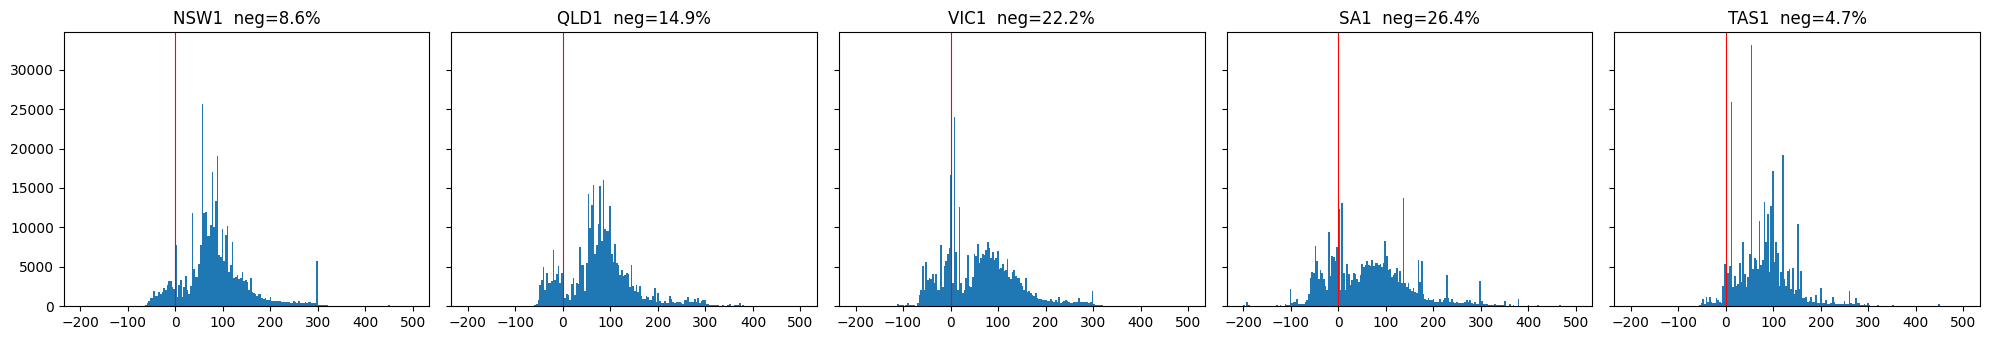

In [2]:
fig, axes = plt.subplots(1, 5, figsize=(20,3.5), sharey=True)
for ax, r in zip(axes, ['NSW1','QLD1','VIC1','SA1','TAS1']):
    s = df.loc[df.REGIONID==r, 'RRP']
    ax.hist(s, bins=200, range=(-200, 500))
    ax.axvline(0, color='r', lw=0.8)
    ax.set_title(f'{r}  neg={100*(s<0).mean():.1f}%')
plt.tight_layout()

## Shape by hour and season

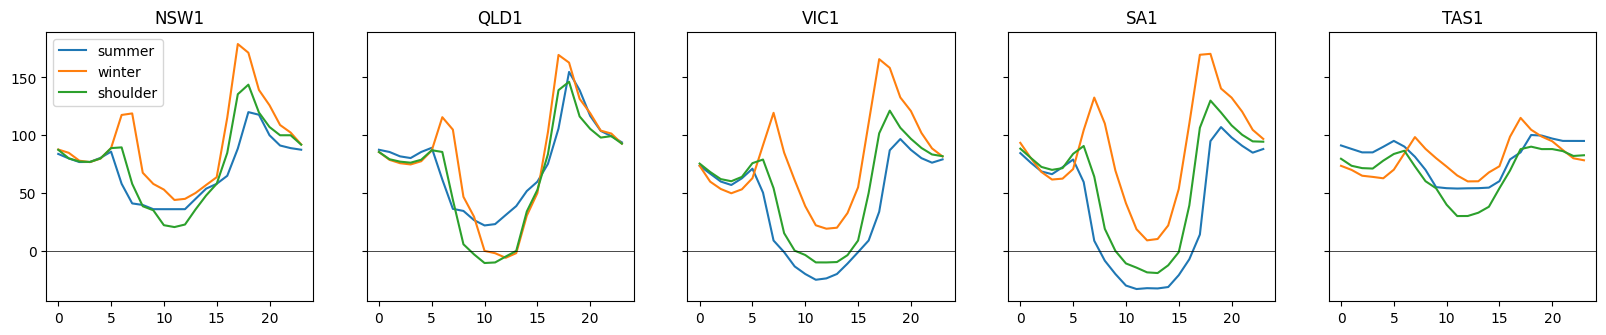

In [3]:
df['season'] = np.where(df.month.isin([12,1,2]), 'summer',
                np.where(df.month.isin([6,7,8]), 'winter', 'shoulder'))

fig, axes = plt.subplots(1, 5, figsize=(20,3.5), sharey=True)
for ax, r in zip(axes, ['NSW1','QLD1','VIC1','SA1','TAS1']):
    sub = df[df.REGIONID==r]
    for s in ['summer','winter','shoulder']:
        g = sub[sub.season==s].groupby('hour').RRP.median()
        ax.plot(g.index, g.values, label=s)
    ax.axhline(0, color='k', lw=0.5); ax.set_title(r)
axes[0].legend()

## Margin against price

Text(0, 0.5, 'RRP')

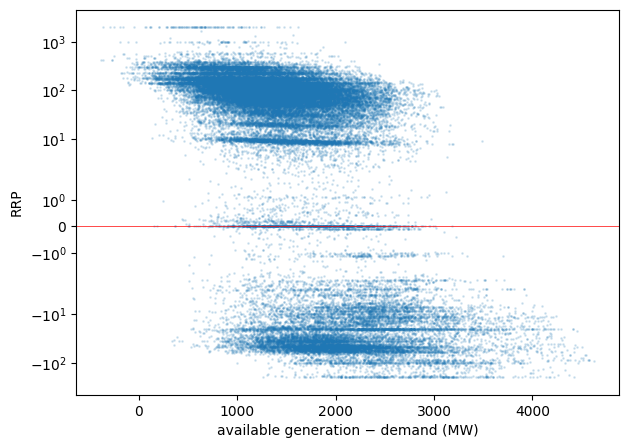

In [4]:
sa = df[df.REGIONID=='SA1'].sample(60000, random_state=0)
plt.figure(figsize=(7,5))
plt.scatter(sa.margin, sa.RRP.clip(-200, 2000), s=1, alpha=0.15)
plt.yscale('symlog'); plt.axhline(0, color='r', lw=0.5)
plt.xlabel('available generation − demand (MW)'); plt.ylabel('RRP')

## Forecast error

In [5]:
sa = df[df.REGIONID=='SA1']
print('demand fc error:', (sa.DEMANDFORECAST - sa.TOTALDEMAND).abs().median().round(1), 'MW')
print('uigf error:     ', sa.uigf_err.abs().median().round(1), 'MW')
print()
print(sa.groupby(pd.qcut(sa.uigf_err, 10, duplicates='drop')).RRP.agg(['median','mean']))

demand fc error: 1369.6 MW
uigf error:      899.6 MW

                                      median        mean
uigf_err                                                
(-2845.9970000000003, -1854.294]  -13.530000  -13.726498
(-1854.294, -1516.859]              0.018025   11.892866
(-1516.859, -1273.248]             22.315830   29.166473
(-1273.248, -1073.437]             43.563720   41.776056
(-1073.437, -899.596]              56.165235   52.745267
(-899.596, -747.139]               69.403195   66.623050
(-747.139, -608.656]               79.768260   81.647693
(-608.656, -464.048]               99.980000  119.348322
(-464.048, -289.32]               137.047295  178.213072
(-289.32, -0.00999]               173.440000  321.314294


/tmp/ipykernel_333097/397035201.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(sa.groupby(pd.qcut(sa.uigf_err, 10, duplicates='drop')).RRP.agg(['median','mean']))


In [6]:
sa[['SETTLEMENTDATE','TOTALDEMAND','DEMANDFORECAST']].head(20)
print(sa.DEMANDFORECAST.describe())

count    376704.000000
mean          0.002561
std          12.780080
min         -74.000000
25%          -8.000000
50%          -3.000000
75%           7.000000
max         152.000000
Name: DEMANDFORECAST, dtype: float64


In [7]:
d = pd.read_parquet('../data/interim/dispatchregionsum.parquet')
print(d.isna().mean().sort_values(ascending=False).head(15))

SETTLEMENTDATE             0.0
REGIONID                   0.0
DISPATCHINTERVAL           0.0
INTERVENTION               0.0
TOTALDEMAND                0.0
AVAILABLEGENERATION        0.0
AVAILABLELOAD              0.0
DEMANDFORECAST             0.0
DISPATCHABLEGENERATION     0.0
DISPATCHABLELOAD           0.0
NETINTERCHANGE             0.0
EXCESSGENERATION           0.0
LOWER5MINLOCALDISPATCH     0.0
LOWER60SECLOCALDISPATCH    0.0
LOWER6SECLOCALDISPATCH     0.0
dtype: float64


In [8]:
for t in [100, 200, 300, 500, 1000, 5000]:
    for r in ['SA1','QLD1','NSW1']:
        s = df[df.REGIONID==r].RRP
        print(f'{r} >{t}: {100*(s>t).mean():.3f}%  n={(s>t).sum()}')
    print()

SA1 >100: 34.521%  n=130043
QLD1 >100: 30.161%  n=113617
NSW1 >100: 32.814%  n=123611

SA1 >200: 8.494%  n=31999
QLD1 >200: 6.248%  n=23536
NSW1 >200: 6.562%  n=24720

SA1 >300: 2.609%  n=9828
QLD1 >300: 1.370%  n=5162
NSW1 >300: 1.111%  n=4186

SA1 >500: 0.595%  n=2243
QLD1 >500: 0.276%  n=1039
NSW1 >500: 0.375%  n=1411

SA1 >1000: 0.234%  n=881
QLD1 >1000: 0.148%  n=558
NSW1 >1000: 0.217%  n=817

SA1 >5000: 0.127%  n=478
QLD1 >5000: 0.070%  n=262
NSW1 >5000: 0.117%  n=440



In [9]:
day = (df.assign(day=df.SETTLEMENTDATE.dt.date)
         .groupby(['REGIONID','day']).RRP.max()
         .gt(300).groupby('REGIONID').mean())
print(day)

REGIONID
NSW1    0.275019
QLD1    0.403361
SA1     0.401833
TAS1    0.285714
VIC1    0.171887
Name: RRP, dtype: float64


In [10]:
from nemosis import defaults
print([t for t in defaults.dynamic_tables if 'PREDISP' in t.upper() or 'P5MIN' in t.upper()])

[]


In [11]:
from nemosis import defaults
print(dir(defaults))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'aemo_mms_url', 'current_data_page_urls', 'data_url', 'date_formats', 'delete_button_internal_row', 'display_as_AMEO', 'display_as_Custom', 'dynamic_tables', 'effective_date_group_col', 'end_time_internal_row', 'end_time_label_internal_row', 'fcas_4_url', 'fcas_4_url_hist', 'filterable_cols', 'header_y_pad', 'internal_filter_row', 'join_type', 'last_column', 'list_column_span', 'list_filter_row_span', 'list_row_span', 'months', 'names', 'names_internal_row', 'nem_data_model_start_time', 'nem_web_domain_url', 'os', 'plus_internal_row', 'plus_merge_internal_row', 'primary_date_columns', 'query_row_offset', 'query_y_pad', 'raw_data_cache', 'reg_exemption_list_tabs', 'return_tables', 'row_height', 'save_field_column_span', 'standard_x_pad', 'start_time_internal_row', 'start_time_label_internal_row', 'static_table_url', 'static_tables', 'table_columns', 'table_list_internal_row', 'tabl

In [12]:
from nemosis import defaults
print(sorted(defaults.dynamic_tables))

['BIDDAYOFFER_D', 'BIDPEROFFER_D', 'DAILY_REGION_SUMMARY', 'DISPATCHCONSTRAINT', 'DISPATCHINTERCONNECTORRES', 'DISPATCHLOAD', 'DISPATCHPRICE', 'DISPATCHREGIONSUM', 'DISPATCH_UNIT_SCADA', 'DUDETAIL', 'DUDETAILSUMMARY', 'FCAS_4_SECOND', 'GENCONDATA', 'INTERCONNECTOR', 'INTERCONNECTORCONSTRAINT', 'INTERMITTENT_GEN_SCADA', 'LOSSFACTORMODEL', 'LOSSMODEL', 'MARKET_PRICE_THRESHOLDS', 'MNSP_DAYOFFER', 'MNSP_INTERCONNECTOR', 'MNSP_PEROFFER', 'NEXT_DAY_DISPATCHLOAD', 'PARTICIPANT', 'ROOFTOP_PV_ACTUAL', 'SPDCONNECTIONPOINTCONSTRAINT', 'SPDINTERCONNECTORCONSTRAINT', 'SPDREGIONCONSTRAINT', 'TRADINGINTERCONNECT', 'TRADINGLOAD', 'TRADINGPRICE', 'TRADINGREGIONSUM']
